In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer

# mpg 데이터셋 로드
mpg = sns.load_dataset('mpg').dropna(subset=['mpg', 'origin'])

# origin별로 데이터 확인
print("Origin별 데이터 개수:")
print(mpg['origin'].value_counts())

Origin별 데이터 개수:
usa       249
japan      79
europe     70
Name: origin, dtype: int64


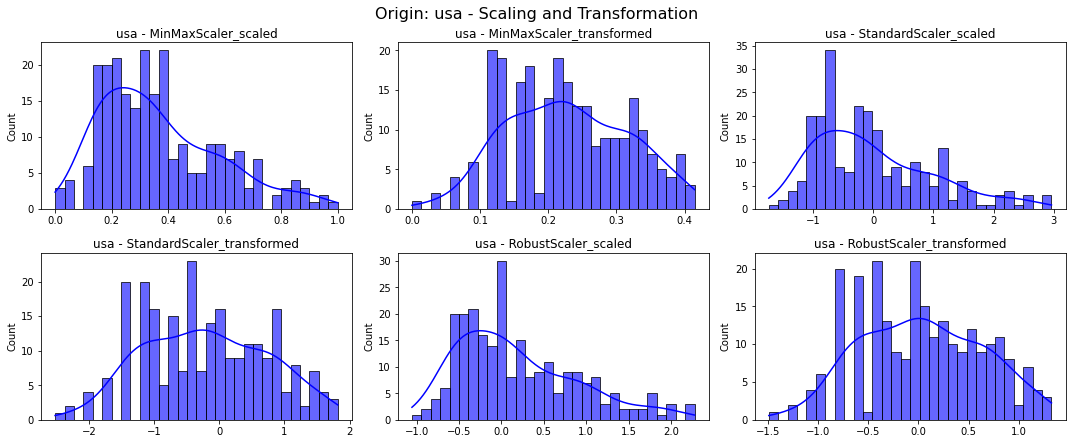

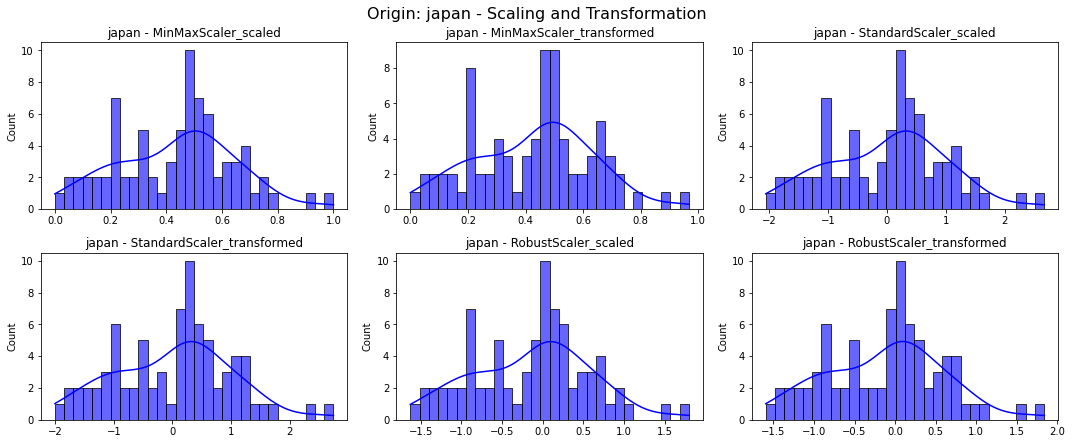

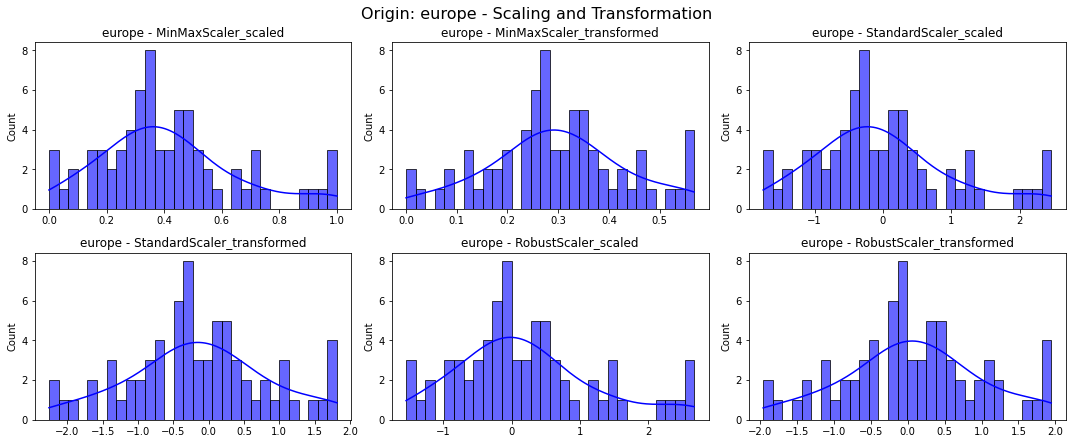

In [15]:
# 스케일링 및 정규분포 변환 함수 정의
def scale_and_transform(data, column, scalers, transformer_method='yeo-johnson'):
    results = {}
    for name, scaler in scalers.items():
        scaled_data = scaler.fit_transform(data[[column]])
        results[f"{name}_scaled"] = scaled_data.ravel()
        
        # 정규분포 변환
        transformer = PowerTransformer(method=transformer_method, standardize=False)
        transformed_data = transformer.fit_transform(scaled_data.reshape(-1, 1))
        results[f"{name}_transformed"] = transformed_data.ravel()
    return results

# 스케일링 방법 정의
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

# Origin별 mpg 데이터 스케일링 및 변환
scaled_transformed_results = {}
for origin in mpg['origin'].unique():
    origin_data = mpg[mpg['origin'] == origin]
    results = scale_and_transform(origin_data, 'mpg', scalers)
    scaled_transformed_results[origin] = results

# 결과 시각화
def plot_comparisons(scaled_transformed_results, origin):
    plt.figure(figsize=(15, 6))
    for i, (key, values) in enumerate(scaled_transformed_results[origin].items(), 1):
        plt.subplot(2, 3, i)
        sns.histplot(values, kde=True, bins=30, color='blue', alpha=0.6)
        plt.title(f"{origin} - {key}")
    plt.tight_layout()
    plt.suptitle(f"Origin: {origin} - Scaling and Transformation", fontsize=16, y=1.02)
    plt.show()

# 시각화: ORIGIN별 스케일링 및 변환 결과
for origin in scaled_transformed_results.keys():
    plot_comparisons(scaled_transformed_results, origin)

## 미국:
- '미국' 자동차의 'mpg' 분포는 가장 편향되어(왼쪽으로 편향됨) 낮은 연비 값이 더 많이 집중되어 있음을 나타냅니다.
- 스케일링 기술(MinMax, Standard, Robust)은 왜도를 약간 감소시키지만 분포를 완전히 정규화하지는 않습니다.

## 일본:
- '일본'은 'mpg' 값이 정규 분포에 더 가까운 것으로 나타났으며, 이는 '미국'에 비해 일반적으로 더 나은 연비를 반영합니다.
- 크기 조정 후에는 특히 RobustScaler에서 데이터가 더 작아지고 변동이 줄어듭니다.

## 유럽:
- '유럽' 자동차의 'mpg' 분포는 '미국' 및 '일본'에 비해 더 균형이 잡혀 있으며 극단값이 더 적습니다.
- 스케일링은 변동성을 더욱 줄여 거의 대칭적인 분포를 달성합니다.